<a href="https://colab.research.google.com/github/Khuc-Ngoc-Nam/Training-AIO-/blob/main/Data_Manipulation_and_Crawling%E2%80%93Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# I. Nội dung
## 1. `Pandas`

## 2. Text Representation using Index-based Encoding

### a) Xây dựng bộ từ vựng (Dictionary)
Từ kho ngữ liệu (tập hợp các văn bản), lọc ra toàn
bộ các từ mới có trong toàn bộ văn bản để tạo lập thành một bộ từ điển.
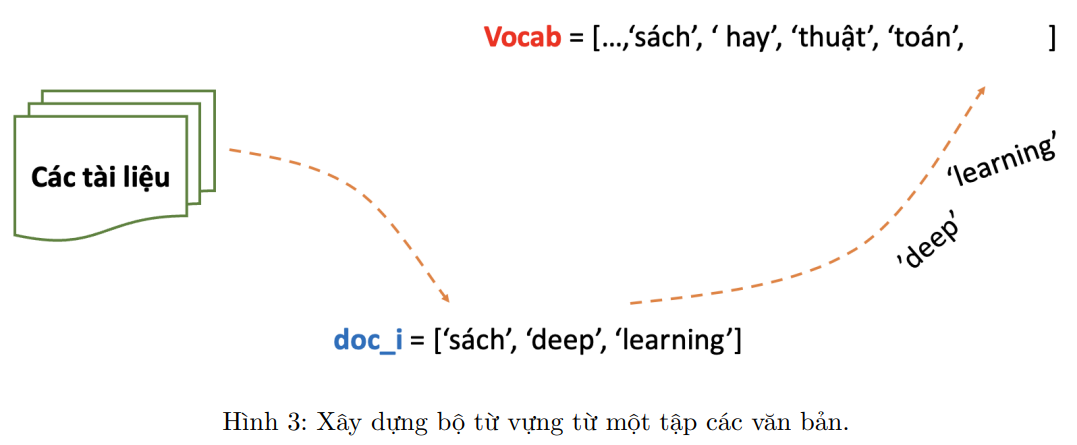

### b) Xây dựng hàm biểu diễn văn bản
`String` -> `vector các số nguyên`

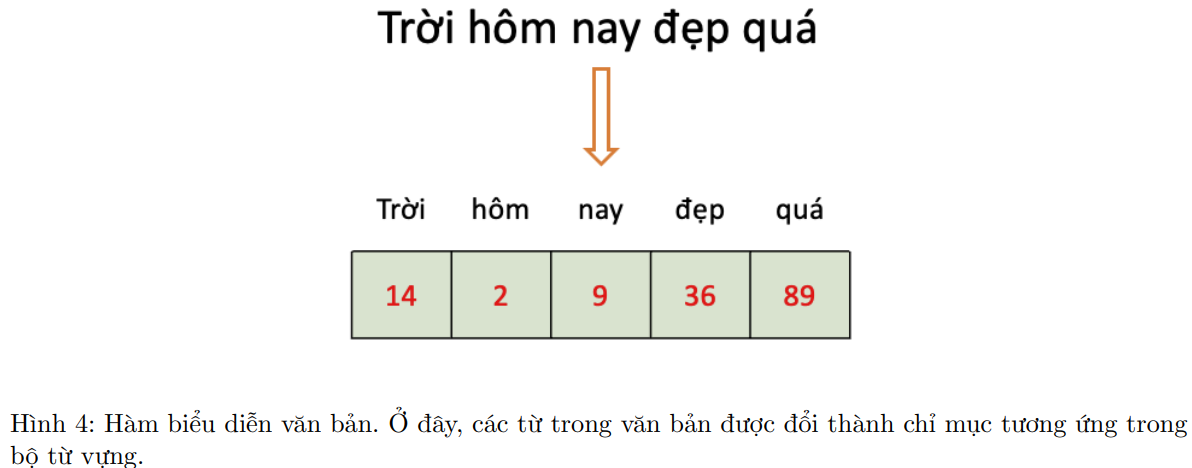

**a) Xây dựng hàm chuẩn hóa văn bản**: Giảm độ phức tạp của văn bản đầu vào

In [1]:
import string

remove_characters = '\t' + string.punctuation   # List kí tự bị loại khỏi văn bản (DẤU CÂU + kí tự Tab)
def text_normalize(text):
    text = text.lower()
    text = text.strip()   # Xóa các khoảng trắng ở rìa văn bản
    text = text.replace('\n', ' ')    # Thay thế kí tự xuống dòng bằng khoảng trắng.
    for char in remove_characters:
        text = text.replace(char, '')

    return text

**b) Xây dựng hàm tạo bộ từ vựng:** Dựa vào danh sách các văn bản, tạo bộ từ vựng bằng cách thu thập toàn bộ các từ (không lấy từ bị lặp lại) trong toàn bộ các văn bản:

In [2]:
def create_dictionary(corpus):
    dictionary = []
    for paragraph in corpus:
        paragraph = text_normalize(paragraph)
        tokens = paragraph.split()
        for token in tokens:
            if token not in dictionary:
                dictionary.append(token)

    return dictionary

**c) Xây dựng hàm biểu diễn văn bản**

In [3]:
def vectorize(text, dictionary, unknown_token_id):
    text = text_normalize(text)
    tokens = text.split()
    vector = [
        dictionary.index(token) if token in dictionary else unknown_token_id
        for token in tokens
    ]

    return vector

**Test**

In [4]:
paragraph = 'Hello World. This is a text representation (vectorization) example'
corpus = [paragraph]
dictionary = create_dictionary(corpus)

text = 'Hello World. My nam is Nam'
unknown_token_id = len(dictionary)
vector = vectorize(text, dictionary, unknown_token_id)

print(vector)

[0, 1, 9, 9, 3, 9]


## 3. Data Crawling:
Data Crawling là một kỹ thuật tự động thu thập dữ liệu từ các trang web. Thông qua việc đọc
và trích xuất thông tin từ file HTML của trang web (Ngôn ngữ đánh dấu siêu văn bản - file xây
dựng cấu trúc các thành phần của một trang web), ta hoàn toàn có thể thu thập được các thông
tin, dữ liệu mong muốn.

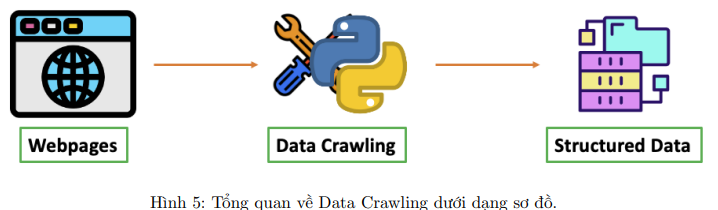

Có rất nhiều thư viện trong Python hỗ trợ tương tác với các website, song ở project này sẽ sử
dụng thư viện $$selenium$$.

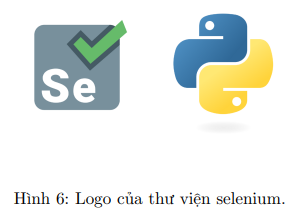

Trong project này, ta sẽ xây dựng một chương trình thu thập các bài báo cùng thuộc một chủ đề
nào đó trên trang [vietnamnet.vn](https://vietnamnet.vn/#vnn_source=trangchu&vnn_medium=logo-top). Tổng quan nội dung các bước thực hiện bao gồm:

- **Bước 1**: Dựa vào đường dẫn URL của một bài báo, request đến server của trang web nội
dung HTML của trang.

- **Bước 2**: Với nội dung HTML nhận được, xác định và tiến hành trích xuất các nội dung của
trang báo sử dụng Selenium.

- **Bước 3**: Lưu nội dung của trang báo dưới dạng file văn bản `.txt`.

- **Bước 4**: Lặp lại 3 bước trên với những trang báo khác.
